In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [2]:
from src.utils import set_seed

from src.data_loader import load_dataset

from src.preprocessing import preprocess_pipeline

from src.model_mlp import (

    train_pipeline,

    predict,

    load_saved_model

)

from src.visualization import (

    plot_loss,

    plot_prediction,

    plot_residual

)

from src.evaluation import regression_metrics

In [3]:
set_seed()

In [4]:
df = load_dataset()

[2026-07-02 11:01:39] Loading dataset : C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\dataset\heartv1.csv
[2026-07-02 11:01:39] Dataset loaded successfully.


In [5]:
data = preprocess_pipeline(df)

[2026-07-02 11:01:39] ============================================================
[2026-07-02 11:01:39] START PREPROCESSING
[2026-07-02 11:01:39] ============================================================
[2026-07-02 11:01:39] Duplicate removed : 723
[2026-07-02 11:01:39] Current rows      : 312
[2026-07-02 11:01:39] Missing values : 0
[2026-07-02 11:01:39] Rows removed : 0
[2026-07-02 11:01:39] Categorical features encoded.
[2026-07-02 11:01:39] Feature shape : (312, 14)
[2026-07-02 11:01:39] Target shape  : (312,)
[2026-07-02 11:01:39] Feature columns saved.
[2026-07-02 11:01:39] Dataset split completed.
[2026-07-02 11:01:39] Train      : 218
[2026-07-02 11:01:39] Validation : 47
[2026-07-02 11:01:39] Test       : 47
[2026-07-02 11:01:39] Scaler saved successfully.
[2026-07-02 11:01:39] Processed datasets saved successfully.
[2026-07-02 11:01:39] ============================================================
[2026-07-02 11:01:39] PREPROCESSING FINISHED
[2026-07-02 11:01:39] ========

In [6]:
model, history = train_pipeline(

    data["X_train"],

    data["y_train"],

    data["X_valid"],

    data["y_valid"]

)

[2026-07-02 11:01:39] ============================================================
[2026-07-02 11:01:39] START MLP TRAINING
[2026-07-02 11:01:39] ============================================================
[2026-07-02 11:01:39] MLP model created.
[2026-07-02 11:01:39] MLP model compiled.


Model: "HeartWiseMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RiskScore (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

[2026-07-02 11:01:39] Starting MLP training...
Epoch 1/150
1/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 106.6862 - mae: 10.1571 - rmse: 10.3289
Epoch 1: val_loss improved from None to 140.62054, saving model to C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\models\mlp.keras

Epoch 1: finished saving model to C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\models\mlp.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 110.8667 - mae: 10.3352 - rmse: 10.5293 - val_loss: 140.6205 - val_mae: 11.6411 - val_rmse: 11.8584 - learning_rate: 0.0010
Epoch 2/150
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 94.9647 - mae: 9.6072 - rmse: 9.7450
Epoch 2: val_loss improved from 140.62054 to 137.59555, saving model to C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\models\mlp.keras

Epoch 2: finished saving model to C:\Users\LENOVO\Documents\kuliah\smt 4\mlp\UAS\models\mlp.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 100.9906 - mae: 9.8597 - rmse: 10.0494 - val_loss: 137.5956 - val_mae: 11.5240 - 

In [7]:
model.summary()

Model: "HeartWiseMLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RiskScore (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,405 (150.02 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 25,348 (99.02 KB)

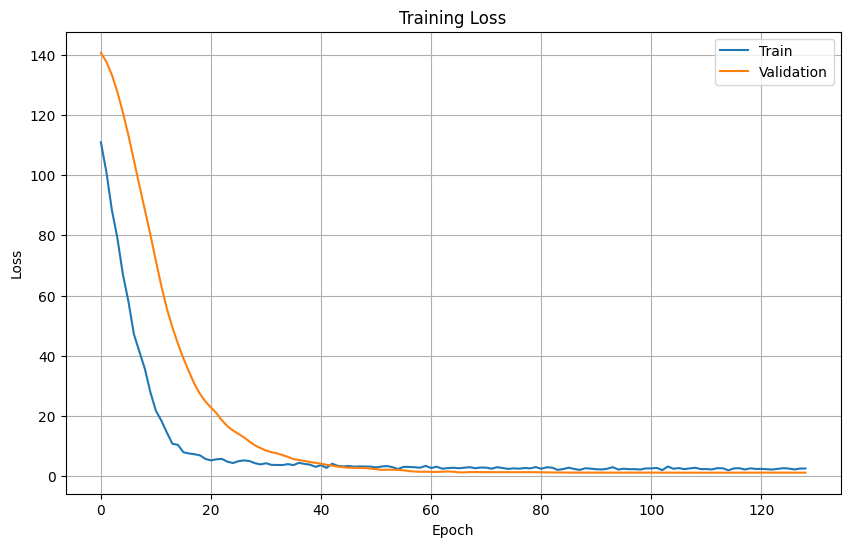

In [8]:
plot_loss(history)

In [9]:
prediction = predict(
    model,
    data["X_test"]
)

In [10]:
prediction[:10]

array([12.589777 ,  9.779914 , 11.2101145, 13.774493 , 13.654534 ,
       11.1113825,  9.499589 , 13.056102 ,  8.7214   , 11.890574 ],
      dtype=float32)

In [11]:
metrics = regression_metrics(
    data["y_test"],
    prediction
)

metrics

[2026-07-02 11:01:54] Evaluation completed.


,MAE,RMSE,MAPE,R2
MLP,0.781542,1.016644,6.533929,0.807009


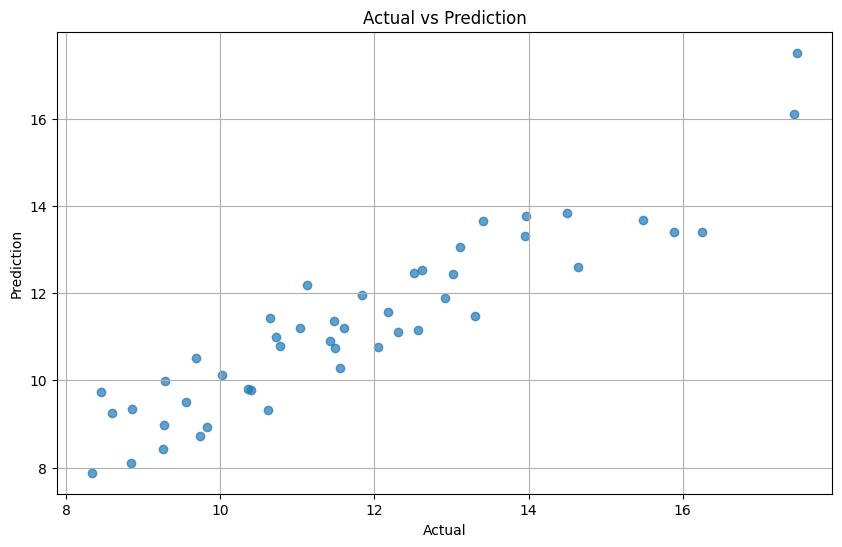

In [12]:
plot_prediction(
    data["y_test"],
    prediction
)

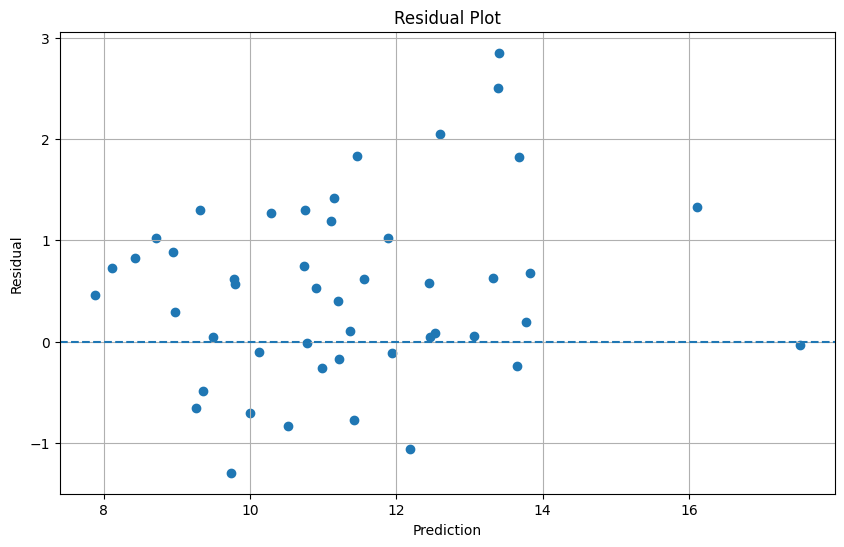

In [13]:
plot_residual(
    data["y_test"],
    prediction
)

In [14]:
loaded_model = load_saved_model()

loaded_prediction = predict(
    loaded_model,
    data["X_test"]
)

loaded_prediction[:5]

[2026-07-02 11:03:05] Loading trained MLP model...
[2026-07-02 11:03:06] Model loaded successfully.


array([12.589777 ,  9.779914 , 11.2101145, 13.774493 , 13.654534 ],
      dtype=float32)